In [ ]:
from pathlib import Path 
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import random
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import tensorflow as tf
from tensorflow.keras import layers, Model
import os
from tensorflow.keras.utils import to_categorical


In [138]:
# ===============================
# 0. Reproducibilidad global
# ===============================

SEED = 42

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# TensorFlow
tf.random.set_seed(SEED)

# Opcional: determinismo en GPU (más lento pero reproducible)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

print("Semilla global fijada en:", SEED)

Semilla global fijada en: 42


In [139]:
# ===============================
# 1. Cargar datos procesados
# ===============================

from pathlib import Path
import numpy as np

PROJECT_ROOT = Path().resolve().parent
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

# Cargar splits
X_train = np.load(PROCESSED_PATH / "train" / "X.npy")
y_train = np.load(PROCESSED_PATH / "train" / "y.npy")

X_val = np.load(PROCESSED_PATH / "val" / "X.npy")
y_val = np.load(PROCESSED_PATH / "val" / "y.npy")

# IMPORTANTE:
# Las imágenes YA fueron normalizadas en el notebook anterior.
# Aquí SOLO aseguramos tipo float32.
X_train = X_train.astype("float32")
X_val = X_val.astype("float32")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Pixel range:", X_train.min(), X_train.max())

Train shape: (6482, 128, 128, 3)
Validation shape: (1388, 128, 128, 3)
Pixel range: 0.0 1.0


In [ ]:
# ===============================
# 2. Parámetros principales
# ===============================

input_shape = (128, 128, 3)
latent_dim = 128
num_classes = 2
beta = 0.001

### Encoder

In [ ]:
# ===============================
# 3. Encoder condicional
# ===============================



image_inputs = layers.Input(shape=input_shape)
label_inputs = layers.Input(shape=(num_classes,))

# Expandir label a mapa espacial
label_map = layers.Dense(128 * 128)(label_inputs)
label_map = layers.Reshape((128, 128, 1))(label_map)

# Concatenar imagen + etiqueta
x = layers.Concatenate()([image_inputs, label_map])

x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)

x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)

x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model([image_inputs, label_inputs],
                [z_mean, z_log_var, z],
                name="encoder")

In [142]:
# ===============================
# 4. Sampling
# ===============================

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

In [ ]:
# ===============================
# 5. Decoder condicional
# ===============================

latent_inputs = layers.Input(shape=(latent_dim,))
label_inputs_dec = layers.Input(shape=(num_classes,))

# Concatenar z + label
x = layers.Concatenate()([latent_inputs, label_inputs_dec])

x = layers.Dense(16 * 16 * 256, activation="relu")(x)
x = layers.Reshape((16, 16, 256))(x)

x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)

x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)

decoder_outputs = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

decoder = Model([latent_inputs, label_inputs_dec],
                decoder_outputs,
                name="decoder")

In [ ]:
# ===============================
# 6-7. Conditional VAE
# ===============================

class CVAE(tf.keras.Model):
    def __init__(self, encoder, decoder, beta=1.0):
        super(CVAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        images, labels = inputs
        z_mean, z_log_var, z = self.encoder([images, labels])
        reconstruction = self.decoder([z, labels])
        return reconstruction

    def train_step(self, data):
        (images, labels) = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder([images, labels])
            reconstruction = self.decoder([z, labels])

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(images - reconstruction), axis=(1,2,3))
            )

            kl_loss = tf.reduce_mean(
                -0.5 * tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [ ]:
# ===============================
# 7. Instanciar CVAE
# ===============================



y_train_onehot = to_categorical(y_train, num_classes)
y_val_onehot = to_categorical(y_val, num_classes)

cvae = CVAE(encoder, decoder, beta=beta)

cvae.compile(optimizer=tf.keras.optimizers.Adam())

In [ ]:
history = cvae.fit(
    (X_train, y_train_onehot),
    epochs=70,
    batch_size=32,
    validation_data=((X_val, y_val_onehot),)
)

Epoch 1/35
203/203 ━━━━━━━━━━━━━━━━━━━━ 47s 223ms/step - kl_loss: 296.2792 - loss: 2280.0535 - recon_loss: 2279.7573 - val_kl_loss: 369.6304 - val_loss: 1104.8442 - val_recon_loss: 1104.4749
Epoch 2/35
203/203 ━━━━━━━━━━━━━━━━━━━━ 65s 322ms/step - kl_loss: 399.0753 - loss: 937.5790 - recon_loss: 937.1799 - val_kl_loss: 410.8976 - val_loss: 832.0723 - val_recon_loss: 831.6612
Epoch 3/35
203/203 ━━━━━━━━━━━━━━━━━━━━ 99s 488ms/step - kl_loss: 419.0058 - loss: 762.1002 - recon_loss: 761.6808 - val_kl_loss: 423.9645 - val_loss: 720.7202 - val_recon_loss: 720.2964
Epoch 4/35
203/203 ━━━━━━━━━━━━━━━━━━━━ 93s 462ms/step - kl_loss: 430.6596 - loss: 676.1804 - recon_loss: 675.7498 - val_kl_loss: 436.6103 - val_loss: 675.0494 - val_recon_loss: 674.6129
Epoch 5/35
203/203 ━━━━━━━━━━━━━━━━━━━━ 95s 468ms/step - kl_loss: 434.4010 - loss: 629.3133 - recon_loss: 628.8789 - val_kl_loss: 437.5276 - val_loss: 641.5071 - val_recon_loss: 641.0696
Epoch 6/35
203/203 ━━━━━━━━━━━━━━━━━━━━ 103s 507ms/step - kl_

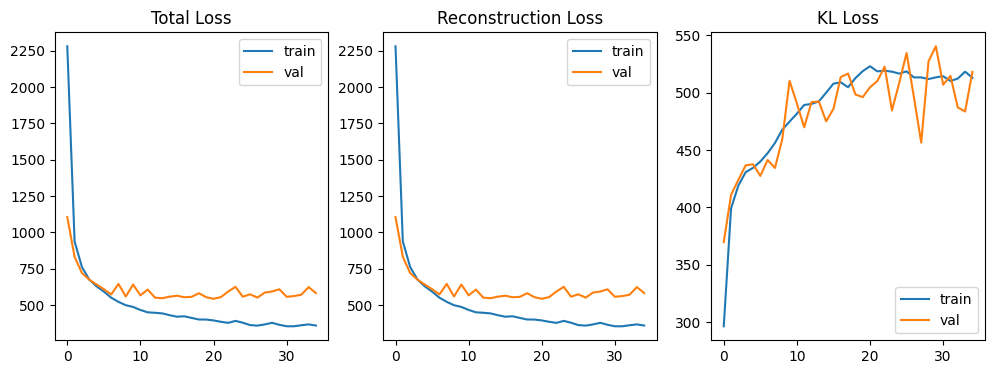

In [148]:
# ===============================
# 8.2 Curvas de entrenamiento
# ===============================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Total Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history["recon_loss"], label="train")
plt.plot(history.history["val_recon_loss"], label="val")
plt.title("Reconstruction Loss")
plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history["kl_loss"], label="train")
plt.plot(history.history["val_kl_loss"], label="val")
plt.title("KL Loss")
plt.legend()

plt.show()

In [149]:
# ===============================
# 8.3 Evaluación objetiva externa
# ===============================

from sklearn.metrics import mean_squared_error

recon_val = vae.predict(X_val)

mse_val = mean_squared_error(
    X_val.reshape(len(X_val), -1),
    recon_val.reshape(len(recon_val), -1)
)

print("Validation MSE:", mse_val)

44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step
Validation MSE: 0.011931738816201687


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


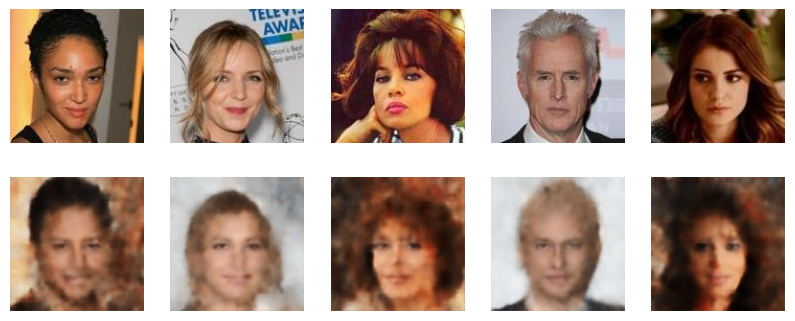

In [150]:
# ===============================
# 9. Visualizar reconstrucciones
# ===============================

recon = vae.predict(X_val[:5])

plt.figure(figsize=(10,4))

for i in range(5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(X_val[i])
    plt.axis("off")
    
    # Reconstruida
    plt.subplot(2,5,i+6)
    plt.imshow(recon[i])
    plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


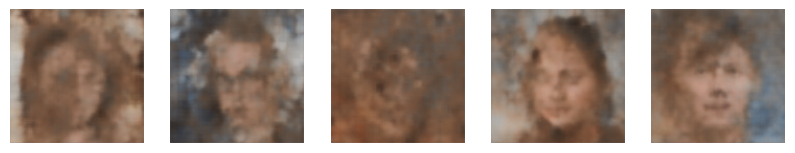

In [ ]:
# Generar imágenes clase REAL
n = 5
z_sample = np.random.normal(size=(n, latent_dim))

labels_real = np.zeros((n, num_classes))
labels_real[:, 0] = 1  # clase real

generated = decoder.predict([z_sample, labels_real])

plt.figure(figsize=(10,2))
for i in range(n):
    plt.subplot(1,n,i+1)
    plt.imshow(generated[i])
    plt.axis("off")
plt.show()